<a href="https://colab.research.google.com/github/GIND123/Symbolic-Sequence-Learning/blob/main/notebooks/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tarfile
import requests

# Dropbox direct download link (convert dl=0 → dl=1)
url = "https://www.dropbox.com/s/7kgfr00qpokgz8w/Feynman_with_units.tar.gz?dl=1"

output_file = "Feynman_with_units.tar.gz"
extract_dir = "Feynman_with_units"

# Download
response = requests.get(url, stream=True)
response.raise_for_status()

with open(output_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete.")

# Extract
os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(output_file, "r:gz") as tar:
    tar.extractall(path=extract_dir)

print(f"Extracted to: {extract_dir}")

Download complete.


/tmp/ipykernel_688/2921588110.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extracted to: Feynman_with_units


In [ ]:
import os

base_dir = "/content/Feynman_with_units"

for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for f in files:
        print(f"{indent}    {f}")

Feynman_with_units/
    Feynman_with_units/
        I.39.1
        I.44.4
        II.21.32
        I.14.4
        I.12.1
        I.15.3t
        II.11.7
        II.27.18
        II.10.9
        II.36.38
        II.11.20
        III.13.18
        I.34.8
        I.26.2
        II.37.1
        II.13.23
        II.34.11
        II.34.29b
        II.38.3
        III.19.51
        I.6.2
        I.24.6
        II.15.5
        I.29.4
        III.10.19
        II.34.29a
        II.3.24
        I.8.14
        I.11.19
        I.13.12
        I.48.20
        II.2.42
        III.15.27
        I.12.4
        I.27.6
        III.4.33
        I.12.11
        II.34.2
        III.17.37
        I.50.26
        I.6.2b
        III.9.52
        II.11.28
        II.11.27
        I.41.16
        I.32.17
        III.15.12
        I.18.12
        II.8.7
        I.14.3
        I.38.12
        II.13.34
        III.7.38
        II.11.3
        I.32.5
        II.6.11
        I.25.13
        I.18.14
        III.4.32


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Papers/GSOC/FeynmanEquations.csv"

df = pd.read_csv(file_path)

print("First 5 rows:\n")
print(df.head())

print("\nData statistics:\n")
print(df.describe(include="all"))

First 5 rows:

  Filename  Number Output                                            Formula  \
0   I.6.2a     1.0      f                        exp(-theta**2/2)/sqrt(2*pi)   
1    I.6.2     2.0      f        exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)   
2   I.6.2b     3.0      f  exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...   
3   I.8.14     4.0      d                        sqrt((x2-x1)**2+(y2-y1)**2)   
4   I.9.18     5.0      F         G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)   

   # variables v1_name  v1_low  v1_high v2_name  v2_low  ...  v7_high v8_name  \
0          1.0   theta     1.0      3.0     NaN     NaN  ...      NaN     NaN   
1          2.0   sigma     1.0      3.0   theta     1.0  ...      NaN     NaN   
2          3.0   sigma     1.0      3.0   theta     1.0  ...      NaN     NaN   
3          4.0      x1     1.0      5.0      x2     1.0  ...      NaN     NaN   
4          9.0      m1     1.0      2.0      m2     1.0  ...      2.0      z1   

   v8_low  v8_hig

Device: cuda
GPU: NVIDIA A100-SXM4-40GB | 42.4 GB
TASK 1.1 — PREPROCESSING & TOKENIZATION
  CSV: 130 rows
  Valid formulas: 100
  Loaded 97 data files
  Could not load 3 (first 3: [('I.15.1', 'not found'), ('I.48.2', 'not found'), ('II.11.17', 'not found')])
  Tokenized: 100/100 | Vocab: 60 | Seq len: 14.7±7.2 (max 38)
  Data files: 97 | Skipped: 0

--- Tokenization Examples ---

  [0] exp(-theta**2/2)/sqrt(2*pi)
       Vars: {'theta': 'x1'}
       Prefix: ['mul', 'mul', 'mul', '0.5', 'sqrt', '2', 'pow', 'pi', '-0.5', 'exp', 'mul', '-0.5', 'pow', 'x1', '2']
       Len: 15

  [1] exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
       Vars: {'sigma': 'x1', 'theta': 'x2'}
       Prefix: ['mul', 'mul', 'mul', 'mul', '0.5', 'sqrt', '2', 'pow', 'pi', '-0.5', 'div', '1', 'x1', 'exp', 'mul', 'mul', '-0.5', 'pow', 'x1', '-2', 'pow', 'x2', '2']
       Len: 23

  [2] exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)
       Vars: {'sigma': 'x1', 'theta': 'x2', 'theta1': 'x3'}
       Prefix: ['mul',

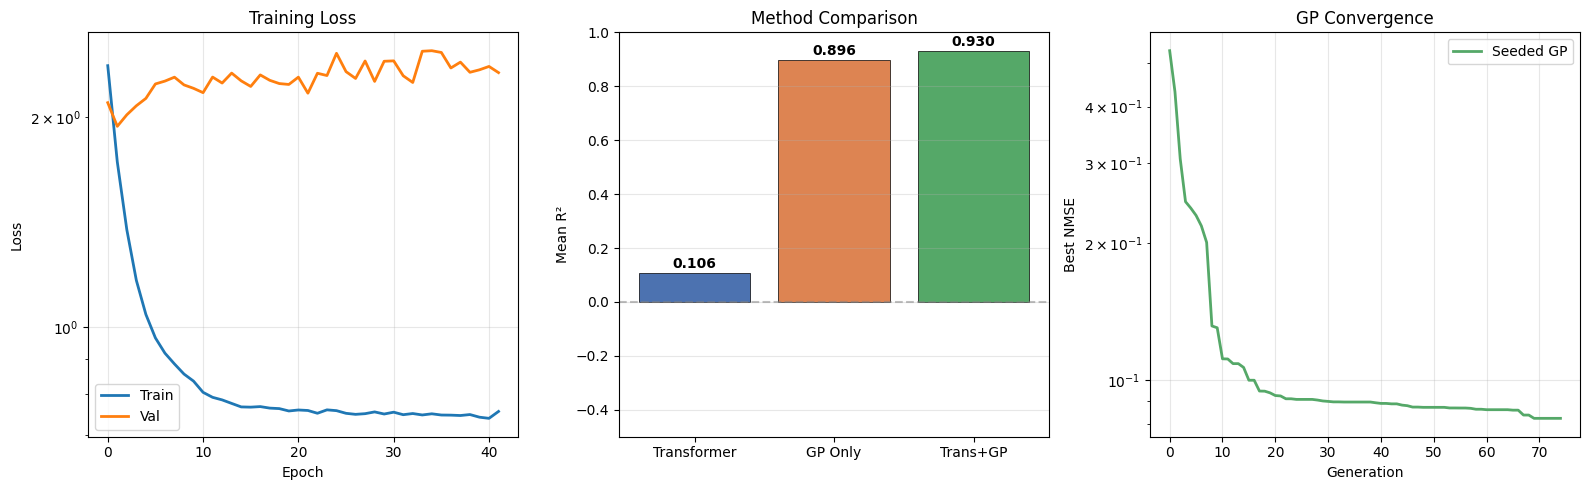

Plot saved
Results saved to results.json

✓ DONE


In [ ]:
"""
================================================================================

Using Next-Gen Transformers to Seed Generative Models for Symbolic Regression
================================================================================

Structure:
  PART 1 — Task 1.1: Dataset Preprocessing & Tokenization
  PART 2 — Task 2.6: Set Transformer + GP Seeding Pipeline
  PART 3 — Evaluation & Ablation Studies
"""



import os, re, math, json, time, random, warnings
from copy import deepcopy
from collections import Counter
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import sympy
from sympy import symbols
from sympy.parsing.sympy_parser import (
    parse_expr, standard_transformations, implicit_multiplication_application
)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)} | {props.total_memory / 1e9:.1f} GB")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ══════════════════════════════════════════════════════════════════════════════
# === PATHS ===
EQUATIONS_CSV = "/content/drive/MyDrive/Papers/GSOC/FeynmanEquations.csv"
DATA_DIR = "/content/Feynman_with_units"
DATA_DIR_NESTED = "/content/Feynman_with_units/Feynman_with_units"
# ══════════════════════════════════════════════════════════════════════════════


SPECIAL_TOKENS = ['<pad>', '<sos>', '<eos>', '<unk>']
OPERATOR_TOKENS = ['add', 'sub', 'mul', 'div', 'pow', 'neg', 'sqrt', 'exp', 'log',
                   'sin', 'cos', 'tan', 'asin', 'acos', 'atan', 'sinh', 'cosh', 'tanh', 'abs']
CONSTANT_TOKENS = ['pi', 'E']
VARIABLE_TOKENS = [f'x{i}' for i in range(1, 11)]
SYMPY_TO_PREFIX = {
    'Add': 'add', 'Mul': 'mul', 'Pow': 'pow', 'exp': 'exp', 'log': 'log', 'sqrt': 'sqrt',
    'sin': 'sin', 'cos': 'cos', 'tan': 'tan', 'asin': 'asin', 'acos': 'acos', 'atan': 'atan',
    'Abs': 'abs', 'tanh': 'tanh', 'cosh': 'cosh', 'sinh': 'sinh',
}

def normalize_formula(s):
    s = s.strip().replace('^', '**')
    s = re.sub(r'(\d)([a-zA-Z])', r'\1*\2', s)
    return s.replace('arcsin', 'asin').replace('arccos', 'acos').replace('arctan', 'atan')

def build_variable_map(row):
    var_map = {}
    try: n_vars_raw = row['# variables']
    except: n_vars_raw = None
    if n_vars_raw is not None and not (isinstance(n_vars_raw, float) and np.isnan(n_vars_raw)):
        n_vars = int(n_vars_raw)
    else:
        n_vars = 0
        for i in range(1, 11):
            try:
                val = row[f'v{i}_name']
                if pd.notna(val) and str(val).strip(): n_vars = i
                else: break
            except: break
    for i in range(1, n_vars + 1):
        try:
            val = row[f'v{i}_name']
            if pd.notna(val) and str(val).strip():
                var_map[str(val).strip()] = f'x{i}'
        except: pass
    return var_map

def substitute_variables(s, var_map):
    for vname in sorted(var_map.keys(), key=len, reverse=True):
        s = re.sub(rf'\b{re.escape(vname)}\b', var_map[vname], s)
    return s

def encode_number(val):
    if val == int(val) and abs(val) <= 100: return str(int(val))
    if abs(val - np.pi) < 1e-10: return 'pi'
    return f'{val:.6g}'

def sympy_to_prefix(expr):
    if expr.is_Symbol: return [str(expr)]
    if expr.is_Number: return [encode_number(float(expr))]
    if expr == sympy.pi: return ['pi']
    if expr == sympy.E: return ['E']
    if expr.is_Mul and expr.args[0] == -1 and len(expr.args) == 2:
        return ['neg'] + sympy_to_prefix(expr.args[1])
    func_name = type(expr).__name__
    if func_name in SYMPY_TO_PREFIX:
        op = SYMPY_TO_PREFIX[func_name]; args = expr.args
        if op in ('add', 'mul') and len(args) > 2:
            result = sympy_to_prefix(args[0])
            for arg in args[1:]: result = [op] + result + sympy_to_prefix(arg)
            return result
        elif op in ('add', 'mul') and len(args) == 2:
            return [op] + sympy_to_prefix(args[0]) + sympy_to_prefix(args[1])
        elif op == 'pow':
            base, ev = args
            if ev == sympy.Rational(1, 2): return ['sqrt'] + sympy_to_prefix(base)
            elif ev == -1: return ['div', '1'] + sympy_to_prefix(base)
            return [op] + sympy_to_prefix(base) + sympy_to_prefix(ev)
        else:
            ct = []
            for arg in args: ct.extend(sympy_to_prefix(arg))
            return [op] + ct
    if expr.is_Mul:
        numer, denom = expr.as_numer_denom()
        if denom != 1: return ['div'] + sympy_to_prefix(numer) + sympy_to_prefix(denom)
        args = expr.args; result = sympy_to_prefix(args[0])
        for arg in args[1:]: result = ['mul'] + result + sympy_to_prefix(arg)
        return result
    if hasattr(expr, 'args') and len(expr.args) > 0:
        tokens = [type(expr).__name__.lower()]
        for arg in expr.args: tokens.extend(sympy_to_prefix(arg))
        return tokens
    return [str(expr)]

def prefix_to_infix(tokens):
    bops = {'add':'+','sub':'-','mul':'*','div':'/','pow':'**'}
    uops = {'neg','sqrt','exp','log','sin','cos','tan','asin','acos','atan','sinh','cosh','tanh','abs'}
    stack = []
    for tok in reversed(tokens):
        if tok in bops:
            a = stack.pop() if stack else '?'; b = stack.pop() if stack else '?'
            stack.append(f'({a} {bops[tok]} {b})')
        elif tok in uops:
            a = stack.pop() if stack else '?'; stack.append(f'{tok}({a})')
        else: stack.append(tok)
    return stack[0] if stack else ''

def find_data_file(filename, search_dirs):
    for d in search_dirs:
        path = os.path.join(d, filename)
        if os.path.exists(path): return path
    return None

def load_numerical_data(df, search_dirs):
    data_samples = {}; loaded, failed = 0, []
    for _, row in df.iterrows():
        fr = row.get('Filename', None)
        if fr is None or (isinstance(fr, float) and np.isnan(fr)): continue
        fname = str(fr).strip()
        path = find_data_file(fname, search_dirs)
        if path:
            try:
                arr = np.loadtxt(path)
                if arr.ndim == 2 and arr.shape[0] >= 10: data_samples[fname] = arr; loaded += 1
                else: failed.append((fname, f"shape {arr.shape}"))
            except Exception as e: failed.append((fname, str(e)[:50]))
        else: failed.append((fname, "not found"))
    print(f"  Loaded {loaded} data files")
    if failed: print(f"  Could not load {len(failed)} (first 3: {failed[:3]})")
    return data_samples

def preprocess_feynman(equations_csv, search_dirs):
    df = pd.read_csv(equations_csv)
    print(f"  CSV: {len(df)} rows")
    df = df.dropna(subset=['Formula']).reset_index(drop=True)
    print(f"  Valid formulas: {len(df)}")
    tokenized, var_maps, skipped = [], [], []
    for idx, row in df.iterrows():
        formula_str = str(row['Formula']).strip()
        fname_raw = row.get('Filename', f'eq_{idx}')
        filename = str(fname_raw).strip() if pd.notna(fname_raw) else f"eq_{idx}"
        var_map = build_variable_map(row); var_maps.append(var_map)
        try:
            norm = normalize_formula(formula_str)
            subst = substitute_variables(norm, var_map)
            ld = {f'x{i}': symbols(f'x{i}') for i in range(1, 11)}; ld['pi'] = sympy.pi
            expr = parse_expr(subst, local_dict=ld,
                              transformations=standard_transformations + (implicit_multiplication_application,))
            tokenized.append(sympy_to_prefix(expr))
        except Exception as e:
            skipped.append((idx, filename, str(e)[:80])); tokenized.append(None)

    tc = Counter()
    for t in tokenized:
        if t is not None: tc.update(t)
    vocab = {}; vid = 0
    for tok in SPECIAL_TOKENS + OPERATOR_TOKENS + CONSTANT_TOKENS + VARIABLE_TOKENS:
        vocab[tok] = vid; vid += 1
    for tok, _ in tc.most_common():
        if tok not in vocab: vocab[tok] = vid; vid += 1

    data_samples = load_numerical_data(df, search_dirs)
    filenames = [str(row.get('Filename', f'eq_{i}')).strip() if pd.notna(row.get('Filename')) else f"eq_{i}"
                 for i, row in df.iterrows()]
    valid = [t for t in tokenized if t is not None]
    lens = [len(t) for t in valid]
    print(f"  Tokenized: {len(valid)}/{len(df)} | Vocab: {len(vocab)} | "
          f"Seq len: {np.mean(lens):.1f}±{np.std(lens):.1f} (max {max(lens)})")
    print(f"  Data files: {len(data_samples)} | Skipped: {len(skipped)}")
    return {'tokenized': tokenized, 'vocab': vocab, 'var_maps': var_maps,
            'data_samples': data_samples, 'filenames': filenames, 'dataframe': df}



print("=" * 60)
print("TASK 1.1 — PREPROCESSING & TOKENIZATION")
print("=" * 60)
assert os.path.exists(EQUATIONS_CSV), f"Not found: {EQUATIONS_CSV}"

search_dirs = []
for d in [DATA_DIR, DATA_DIR_NESTED]:
    if d and os.path.isdir(d):
        search_dirs.append(d)
        for sub in os.listdir(d):
            sp = os.path.join(d, sub)
            if os.path.isdir(sp): search_dirs.append(sp)
if not search_dirs: search_dirs = [DATA_DIR]

dataset = preprocess_feynman(EQUATIONS_CSV, search_dirs)

print("\n--- Tokenization Examples ---")
ct = 0
for i in range(len(dataset['tokenized'])):
    t = dataset['tokenized'][i]
    if t is not None:
        f = str(dataset['dataframe'].iloc[i]['Formula'])
        print(f"\n  [{i}] {f}\n       Vars: {dataset['var_maps'][i]}\n       Prefix: {t}\n       Len: {len(t)}")
        ct += 1
        if ct >= 5: break


class MAB(nn.Module):
    def __init__(self, d, h, drop=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, h, dropout=drop, batch_first=True)
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d,4*d), nn.GELU(), nn.Dropout(drop), nn.Linear(4*d,d), nn.Dropout(drop))
    def forward(self, Q, K):
        h = self.ln1(Q + self.attn(Q, K, K)[0]); return self.ln2(h + self.ff(h))

class ISAB(nn.Module):
    def __init__(self, d, h, m=32, drop=0.1):
        super().__init__()
        self.I = nn.Parameter(torch.randn(1, m, d) * 0.02)
        self.mab1 = MAB(d, h, drop); self.mab2 = MAB(d, h, drop)
    def forward(self, X):
        H = self.mab1(self.I.expand(X.size(0),-1,-1), X); return self.mab2(X, H)

class SetEncoder(nn.Module):
    def __init__(self, input_dim=11, d=256, h=8, n_layers=3, m=32, n_latent=16, drop=0.1):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(input_dim, d), nn.GELU(), nn.LayerNorm(d), nn.Linear(d, d))
        self.layers = nn.ModuleList([ISAB(d, h, m, drop) for _ in range(n_layers)])
        self.seeds = nn.Parameter(torch.randn(1, n_latent, d) * 0.02)
        self.pool = MAB(d, h, drop)
    def forward(self, x):
        h = self.proj(x)
        for layer in self.layers: h = layer(h)
        return self.pool(self.seeds.expand(x.size(0),-1,-1), h)

class PosEnc(nn.Module):
    def __init__(self, d, max_len=128, drop=0.1):
        super().__init__()
        self.dropout = nn.Dropout(drop)
        pe = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float() * (-math.log(10000.0)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return self.dropout(x + self.pe[:, :x.size(1)])

class Decoder(nn.Module):
    def __init__(self, vocab_size, d=256, h=8, n_layers=4, max_len=64, drop=0.1):
        super().__init__()
        self.d = d; self.embed = nn.Embedding(vocab_size, d, padding_idx=0)
        self.pos = PosEnc(d, max_len, drop)
        layer = nn.TransformerDecoderLayer(d, h, 4*d, drop, 'gelu', batch_first=True)
        self.dec = nn.TransformerDecoder(layer, n_layers)
        self.out = nn.Linear(d, vocab_size)
    def forward(self, tgt_ids, memory, mask=None):
        sl = tgt_ids.size(1)
        if mask is None: mask = nn.Transformer.generate_square_subsequent_mask(sl, device=tgt_ids.device)
        h = self.pos(self.embed(tgt_ids) * math.sqrt(self.d))
        return self.out(self.dec(h, memory, tgt_mask=mask, tgt_key_padding_mask=(tgt_ids==0)))

class SymRegTransformer(nn.Module):
    def __init__(self, vocab_size, input_dim=11, d=256, h=8, enc_layers=3,
                 dec_layers=4, m=32, n_latent=16, max_len=64, drop=0.1):
        super().__init__()
        self.encoder = SetEncoder(input_dim, d, h, enc_layers, m, n_latent, drop)
        self.decoder = Decoder(vocab_size, d, h, dec_layers, max_len, drop)
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, points, tgt_ids):
        return self.decoder(tgt_ids, self.encoder(points))

    @torch.no_grad()
    def beam_search(self, points, sos_id, eos_id, beam_width=10, max_len=64):
        self.eval(); memory = self.encoder(points); all_results = []
        for b in range(points.size(0)):
            mem = memory[b:b+1]; beams = [(0.0, [sos_id])]; completed = []
            for _ in range(max_len):
                cands = []
                for score, seq in beams:
                    if seq[-1] == eos_id: completed.append((score, seq)); continue
                    tgt = torch.tensor([seq], dtype=torch.long, device=points.device)
                    logits = self.decoder(tgt, mem)
                    lp = F.log_softmax(logits[0,-1], dim=-1)
                    topk_lp, topk_ids = torch.topk(lp, beam_width)
                    for l, t in zip(topk_lp.tolist(), topk_ids.tolist()):
                        cands.append((score+l, seq+[t]))
                cands.sort(key=lambda x: x[0], reverse=True); beams = cands[:beam_width]
                if not beams: break
            completed.extend(beams); completed.sort(key=lambda x: x[0], reverse=True)
            all_results.append([seq for _, seq in completed[:beam_width]])
        return all_results



class SRDataset(Dataset):
    def __init__(self, indices, dd, n_pts=200, max_seq=64, max_vars=10,
                 augment=True, repeats=1):
        self.vocab, self.n_pts, self.max_seq, self.max_vars = dd['vocab'], n_pts, max_seq, max_vars
        self.augment = augment
        self.repeats = repeats  # NEW: each equation seen this many times per epoch
        self.samples = []
        for i in indices:
            fname, tokens = dd['filenames'][i], dd['tokenized'][i]
            if tokens is not None and fname in dd['data_samples']:
                arr = dd['data_samples'][fname]
                if arr.ndim == 2 and arr.shape[0] >= 10:
                    self.samples.append({'fname': fname, 'data': arr, 'tokens': tokens})
        print(f"    Dataset: {len(self.samples)} eqs × {repeats} repeats = "
              f"{len(self.samples) * repeats} effective samples")

    def __len__(self):
        return len(self.samples) * self.repeats

    def __getitem__(self, idx):
        s = self.samples[idx % len(self.samples)]
        data = s['data']; n_rows, n_cols = data.shape; n_vars = n_cols - 1

        # Random subsample of observation points (different each time!)
        if self.augment:
            ix = np.random.choice(n_rows, self.n_pts, replace=(n_rows < self.n_pts))
        else:
            ix = np.arange(min(self.n_pts, n_rows))
            if len(ix) < self.n_pts: ix = np.pad(ix, (0, self.n_pts - len(ix)), mode='wrap')

        pts = data[ix].copy()  # .copy() to avoid modifying original

        # Augmentation: add small Gaussian noise to inputs (not output)
        if self.augment:
            noise_scale = 0.01 * np.std(pts[:, :-1], axis=0, keepdims=True) + 1e-10
            pts[:, :-1] += np.random.randn(self.n_pts, n_vars) * noise_scale

        x, y = pts[:, :-1], pts[:, -1:]
        if n_vars < self.max_vars:
            x = np.concatenate([x, np.zeros((self.n_pts, self.max_vars - n_vars))], axis=1)
        elif n_vars > self.max_vars:
            x = x[:, :self.max_vars]

        inp = np.concatenate([x, y], axis=1)
        mu, std = inp.mean(0, keepdims=True), inp.std(0, keepdims=True) + 1e-8
        inp = np.nan_to_num((inp - mu) / std, nan=0.0, posinf=5.0, neginf=-5.0)
        inp = np.clip(inp, -10, 10)  # Clip extreme values

        ids = [self.vocab['<sos>']]
        for tok in s['tokens']: ids.append(self.vocab.get(tok, self.vocab['<unk>']))
        ids.append(self.vocab['<eos>'])
        if len(ids) < self.max_seq: ids += [0] * (self.max_seq - len(ids))
        else: ids = ids[:self.max_seq - 1] + [self.vocab['<eos>']]

        return {'input': torch.tensor(inp, dtype=torch.float32),
                'target': torch.tensor(ids, dtype=torch.long),
                'n_vars': n_vars, 'fname': s['fname']}


# ── Genetic Programming ─────────────────────────────────────────────────────

class Node:
    def __init__(self, value, children=None):
        self.value = value; self.children = children or []
    def is_leaf(self): return len(self.children) == 0
    def depth(self): return 0 if self.is_leaf() else 1 + max(c.depth() for c in self.children)
    def size(self): return 1 if self.is_leaf() else 1 + sum(c.size() for c in self.children)
    def __repr__(self):
        if self.is_leaf(): return str(self.value)
        if len(self.children) == 1: return f"{self.value}({self.children[0]})"
        return f"({self.children[0]} {self.value} {self.children[1]})"

BINARY_OPS = {
    'add': lambda a,b: a+b, 'sub': lambda a,b: a-b, 'mul': lambda a,b: a*b,
    'div': lambda a,b: np.where(np.abs(b)>1e-10, a/b, 1.0),
    'pow': lambda a,b: np.where((a>0)|(b==np.round(b)), np.power(np.abs(a)+1e-10, np.clip(b,-5,5)), 0.0),
}
UNARY_OPS = {
    'neg': lambda a: -a, 'sqrt': lambda a: np.sqrt(np.abs(a)+1e-10),
    'exp': lambda a: np.exp(np.clip(a,-10,10)), 'log': lambda a: np.log(np.abs(a)+1e-10),
    'sin': np.sin, 'cos': np.cos, 'tan': lambda a: np.tan(np.clip(a,-1.5,1.5)), 'abs': np.abs,
}

def prefix_to_tree(tokens, variables=None):
    if variables is None: variables = [f'x{i}' for i in range(1, 11)]
    idx = [0]
    def parse():
        if idx[0] >= len(tokens): return Node('1')
        tok = tokens[idx[0]]; idx[0] += 1
        if tok in ('<sos>','<eos>','<pad>','<unk>'):
            return parse() if idx[0] < len(tokens) else Node('1')
        if tok in BINARY_OPS: return Node(tok, [parse(), parse()])
        if tok in UNARY_OPS: return Node(tok, [parse()])
        if tok in variables: return Node(tok)
        try: float(tok); return Node(tok)
        except:
            if tok == 'pi': return Node(str(np.pi))
            if tok == 'E': return Node(str(np.e))
            return Node('1')
    try: return parse()
    except: return Node('1')

def eval_tree(node, X, variables=None):
    if variables is None: variables = [f'x{i}' for i in range(1, X.shape[1]+1)]
    v2c = {v: i for i, v in enumerate(variables)}
    def _e(n):
        if n.is_leaf():
            if n.value in v2c: return X[:, v2c[n.value]].copy()
            try: return np.full(X.shape[0], float(n.value))
            except: return np.ones(X.shape[0])
        if n.value in UNARY_OPS: return UNARY_OPS[n.value](_e(n.children[0]))
        if n.value in BINARY_OPS: return BINARY_OPS[n.value](_e(n.children[0]), _e(n.children[1]))
        return np.ones(X.shape[0])
    try: return np.nan_to_num(_e(node), nan=1e6, posinf=1e6, neginf=-1e6)
    except: return np.full(X.shape[0], 1e6)

def fitness_nmse(tree, X, y, v=None):
    yp = eval_tree(tree, X, v); return np.mean((y-yp)**2)/(np.var(y)+1e-10) + 0.001*tree.size()
def fitness_r2(tree, X, y, v=None):
    yp = eval_tree(tree, X, v); return 1.0 - np.sum((y-yp)**2)/(np.sum((y-np.mean(y))**2)+1e-10)
def random_tree(depth, variables, p_leaf=0.3):
    if depth <= 0 or (depth <= 2 and random.random() < p_leaf):
        return Node(random.choice(variables) if random.random()<0.7 else str(round(random.uniform(-5,5),2)))
    if random.random() < 0.3:
        return Node(random.choice(list(UNARY_OPS.keys())), [random_tree(depth-1, variables)])
    op = random.choice(list(BINARY_OPS.keys()))
    return Node(op, [random_tree(depth-1, variables), random_tree(depth-1, variables)])
def _collect(tree):
    r = [(None, 0)]
    def _t(n):
        for i, c in enumerate(n.children): r.append((n, i)); _t(c)
    _t(tree); return r
def gp_cross(p1, p2):
    c1, c2 = deepcopy(p1), deepcopy(p2)
    n1, n2 = _collect(c1), _collect(c2)
    if len(n1) < 2 or len(n2) < 2: return c1, c2
    pa1, i1 = random.choice(n1[1:]); pa2, i2 = random.choice(n2[1:])
    if pa1 and pa2: pa1.children[i1], pa2.children[i2] = pa2.children[i2], pa1.children[i1]
    return c1, c2
def gp_mut(tree, variables, p=0.1):
    tree = deepcopy(tree)
    def _m(n):
        if random.random() < p:
            if n.is_leaf(): n.value = random.choice(variables) if random.random()<0.5 else str(round(random.uniform(-5,5),2))
            elif len(n.children)==2: n.value = random.choice(list(BINARY_OPS.keys()))
            elif len(n.children)==1: n.value = random.choice(list(UNARY_OPS.keys()))
        for c in n.children: _m(c)
    _m(tree); return tree
def tourn(pop, k=5):
    t = random.sample(pop, min(k, len(pop))); t.sort(key=lambda x: x[0]); return deepcopy(t[0][1])

def run_gp(X, y, seed_trees, variables, pop_size=100, n_gen=50, verbose=True):
    pop = []
    for t in seed_trees:
        if t and t.depth() <= 10: pop.append((fitness_nmse(t, X, y, variables), t))
    for t in seed_trees:
        if t:
            for _ in range(3):  # More variants for exploration
                m = gp_mut(t, variables, 0.3)
                if m.depth() <= 10: pop.append((fitness_nmse(m, X, y, variables), m))
    ns = len(pop)
    while len(pop) < pop_size:
        t = random_tree(5, variables); pop.append((fitness_nmse(t, X, y, variables), t))
    pop.sort(key=lambda x: x[0]); pop = pop[:pop_size]
    if verbose: print(f"    Pop: {ns} seeded + {pop_size-ns} random | Init NMSE: {pop[0][0]:.6f}")
    hist = {'best': [], 'avg': [], 'r2': []}
    for gen in range(n_gen):
        en = max(2, pop_size // 10)  # Keep top 10% as elite
        new_pop = [(f, deepcopy(t)) for f, t in pop[:en]]
        while len(new_pop) < pop_size:
            if random.random() < 0.7:
                c1, c2 = gp_cross(tourn(pop), tourn(pop))
                for c in [c1, c2]:
                    if c.depth() <= 10: new_pop.append((fitness_nmse(c, X, y, variables), c))
            else:
                c = gp_mut(tourn(pop), variables, 0.15)
                if c.depth() <= 10: new_pop.append((fitness_nmse(c, X, y, variables), c))
        new_pop.sort(key=lambda x: x[0]); pop = new_pop[:pop_size]
        bf = pop[0][0]
        hist['best'].append(bf); hist['avg'].append(np.mean([f for f,_ in pop]))
        hist['r2'].append(fitness_r2(pop[0][1], X, y, variables))
        if verbose and (gen % 10 == 0 or gen == n_gen-1):
            print(f"    Gen {gen:3d}: NMSE={bf:.6f}, R²={hist['r2'][-1]:.6f}")
        if bf < 1e-10:
            if verbose: print(f"    Perfect fit at gen {gen}!"); break
    return pop[0][1], pop[0][0], hist



MAX_VARS, N_POINTS, MAX_SEQ = 10, 200, 64
D_MODEL, N_HEADS, ENC_LAYERS, DEC_LAYERS = 256, 8, 3, 4
BATCH_SIZE = 16              # Larger batch with augmented dataset
LR = 3e-4
EPOCHS = 300                 # Can train longer now without overfitting
PATIENCE = 40                # More patience since augmentation adds variance
WARMUP_EPOCHS = 10
LABEL_SMOOTHING = 0.1        # Regularization
TRAIN_REPEATS = 50           # Each equation seen 50x per epoch with different samples
BEAM_WIDTH, GP_POP, GP_GENS = 15, 150, 75  # Bigger search

print("\n" + "=" * 60)
print("DATA SPLITS (80-10-10)")
print("=" * 60)

valid_idx = [i for i in range(len(dataset['filenames']))
             if dataset['tokenized'][i] is not None and dataset['filenames'][i] in dataset['data_samples']]
print(f"  Valid equations: {len(valid_idx)}")

rng = np.random.RandomState(SEED); rng.shuffle(valid_idx)
n = len(valid_idx)
train_idx = valid_idx[:int(0.8*n)]
val_idx = valid_idx[int(0.8*n):int(0.9*n)]
test_idx = valid_idx[int(0.9*n):]
print(f"  train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

train_ds = SRDataset(train_idx, dataset, N_POINTS, MAX_SEQ, MAX_VARS,
                     augment=True, repeats=TRAIN_REPEATS)
val_ds = SRDataset(val_idx, dataset, N_POINTS, MAX_SEQ, MAX_VARS,
                   augment=False, repeats=1)
test_ds = SRDataset(test_idx, dataset, N_POINTS, MAX_SEQ, MAX_VARS,
                    augment=False, repeats=1)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, drop_last=True,
                          num_workers=2, pin_memory=(device.type=='cuda'))
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=(device.type=='cuda'))

vocab_size = len(dataset['vocab'])
model = SymRegTransformer(vocab_size, MAX_VARS+1, D_MODEL, N_HEADS,
                          ENC_LAYERS, DEC_LAYERS, 32, 16, MAX_SEQ, 0.15).to(device)
print(f"\nModel: {sum(p.numel() for p in model.parameters()):,} params | Vocab: {vocab_size}")
print(f"Train batches/epoch: {len(train_loader)} ({len(train_ds)} samples)")

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)  # Stronger weight decay

# Warmup + cosine annealing
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=LABEL_SMOOTHING)

best_val_loss, patience_ctr = float('inf'), 0
train_hist = {'train_loss': [], 'val_loss': [], 'val_acc': []}
use_amp = (device.type == 'cuda')
scaler = torch.amp.GradScaler('cuda') if use_amp else None
t0 = time.time()

for epoch in range(EPOCHS):
    model.train(); total_loss, nb = 0.0, 0
    for batch in train_loader:
        inp = batch['input'].to(device, non_blocking=True)
        tgt = batch['target'].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if use_amp:
            with torch.amp.autocast('cuda'):
                logits = model(inp, tgt[:, :-1])
                loss = criterion(logits.reshape(-1, vocab_size), tgt[:, 1:].reshape(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            logits = model(inp, tgt[:, :-1])
            loss = criterion(logits.reshape(-1, vocab_size), tgt[:, 1:].reshape(-1))
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        total_loss += loss.item(); nb += 1
    scheduler.step(); tl = total_loss / max(nb, 1)

    model.eval(); vl_sum, vc, vt, vnb = 0.0, 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            inp = batch['input'].to(device, non_blocking=True)
            tgt = batch['target'].to(device, non_blocking=True)
            if use_amp:
                with torch.amp.autocast('cuda'):
                    logits = model(inp, tgt[:, :-1])
                    vl_sum += criterion(logits.reshape(-1, vocab_size), tgt[:, 1:].reshape(-1)).item()
            else:
                logits = model(inp, tgt[:, :-1])
                vl_sum += criterion(logits.reshape(-1, vocab_size), tgt[:, 1:].reshape(-1)).item()
            vnb += 1; preds = logits.argmax(-1); mask = tgt[:,1:] != 0
            vc += (preds == tgt[:,1:]).masked_select(mask).sum().item(); vt += mask.sum().item()

    vl, va = vl_sum/max(vnb,1), vc/max(vt,1)
    train_hist['train_loss'].append(tl); train_hist['val_loss'].append(vl); train_hist['val_acc'].append(va)

    if epoch % 10 == 0 or epoch == EPOCHS-1:
        print(f"Ep {epoch:3d} | train={tl:.4f} val={vl:.4f} acc={va:.4f} "
              f"lr={optimizer.param_groups[0]['lr']:.1e} | {time.time()-t0:.0f}s")

    if vl < best_val_loss:
        best_val_loss = vl; patience_ctr = 0; torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}"); break

model.load_state_dict(torch.load('best_model.pt', weights_only=True))
print(f"\nBest val loss: {best_val_loss:.4f} | Time: {time.time()-t0:.0f}s")



print("\n" + "=" * 60)
print("EVALUATION")
print("=" * 60)

inv_vocab = {v: k for k, v in dataset['vocab'].items()}
sos_id, eos_id = dataset['vocab']['<sos>'], dataset['vocab']['<eos>']
results = {'transformer': [], 'transformer_gp': [], 'gp_only': []}
model.eval()

for i in range(len(test_ds)):
    s = test_ds[i]; fname = s['fname']
    raw = dataset['data_samples'].get(fname)
    if raw is None: continue
    X, y = raw[:, :-1], raw[:, -1]
    nv = X.shape[1]; variables = [f'x{j}' for j in range(1, nv+1)]

    # Use subset for GP fitness eval (faster)
    if X.shape[0] > 10000:
        gp_idx = np.random.choice(X.shape[0], 10000, replace=False)
        X_gp, y_gp = X[gp_idx], y[gp_idx]
    else:
        X_gp, y_gp = X, y

    print(f"\n{'─'*50}\n[{i+1}/{len(test_ds)}] {fname} ({nv} vars, {X.shape[0]} pts)")

    inp = s['input'].unsqueeze(0).to(device)
    beams = model.beam_search(inp, sos_id, eos_id, BEAM_WIDTH, MAX_SEQ)
    trees = []
    for seq in beams[0]:
        toks = [inv_vocab.get(t, '<unk>') for t in seq if t not in (sos_id, eos_id, 0)]
        tree = prefix_to_tree(toks, variables)
        if tree: trees.append(tree)

    if trees:
        scores = sorted([(fitness_nmse(t, X_gp, y_gp, variables), t) for t in trees], key=lambda x: x[0])
        t_nmse, t_r2 = scores[0][0], fitness_r2(scores[0][1], X_gp, y_gp, variables)
    else:
        t_nmse, t_r2 = 999.0, -999.0
    print(f"  Transformer:    NMSE={t_nmse:.6f}  R²={t_r2:.6f}")
    results['transformer'].append({'fname': fname, 'nmse': t_nmse, 'r2': t_r2})

    print(f"  Transformer+GP:")
    bt, bf, hist = run_gp(X_gp, y_gp, trees, variables, GP_POP, GP_GENS)
    tgp_r2 = fitness_r2(bt, X_gp, y_gp, variables)
    results['transformer_gp'].append({'fname': fname, 'nmse': bf, 'r2': tgp_r2,
                                       'expr': str(bt)[:100], 'hist': hist})

    print(f"  GP-only:")
    bt2, bf2, _ = run_gp(X_gp, y_gp, [], variables, GP_POP, GP_GENS)
    gp_r2 = fitness_r2(bt2, X_gp, y_gp, variables)
    results['gp_only'].append({'fname': fname, 'nmse': bf2, 'r2': gp_r2})


# ── Summary ──────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("FINAL METRICS")
print("=" * 70)
for method, label in [('transformer', 'Transformer Only'), ('gp_only', 'GP Only (Random)'),
                      ('transformer_gp', 'Transformer + GP (Ours)')]:
    entries = results[method]
    if not entries: continue
    nmses = [e['nmse'] for e in entries]; r2s = [max(e['r2'], -1.0) for e in entries]
    print(f"\n  {label}:")
    print(f"    Mean NMSE:   {np.mean(nmses):.6f} ± {np.std(nmses):.6f}")
    print(f"    Median NMSE: {np.median(nmses):.6f}")
    print(f"    Mean R²:     {np.mean(r2s):.6f} ± {np.std(r2s):.6f}")
    print(f"    Median R²:   {np.median(r2s):.6f}")
    print(f"    R² > 0.9:    {sum(1 for r in r2s if r>0.9)}/{len(entries)}")
    print(f"    R² > 0.99:   {sum(1 for r in r2s if r>0.99)}/{len(entries)}")
    print(f"    NMSE < 0.01: {sum(1 for n in nmses if n<0.01)}/{len(entries)}")

if results['transformer_gp'] and results['gp_only']:
    imps = [(g['nmse']-t['nmse'])/g['nmse']*100
            for t, g in zip(results['transformer_gp'], results['gp_only']) if g['nmse']>1e-10]
    if imps:
        print(f"\n  ABLATION — Seeding Benefit:")
        print(f"    Mean improvement:   {np.mean(imps):.1f}%")
        print(f"    Median improvement: {np.median(imps):.1f}%")
        print(f"    Helped: {sum(1 for x in imps if x>0)}/{len(imps)} equations")


# ── Plots ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(train_hist['train_loss'], label='Train', lw=2)
axes[0].plot(train_hist['val_loss'], label='Val', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[0].legend(); axes[0].set_yscale('log'); axes[0].grid(True, alpha=0.3)

labels = ['Transformer', 'GP Only', 'Trans+GP']
r2m = [np.mean([max(e['r2'],-1) for e in results[k]]) if results[k] else 0
       for k in ['transformer', 'gp_only', 'transformer_gp']]
bars = axes[1].bar(labels, r2m, color=['#4C72B0','#DD8452','#55A868'], edgecolor='black', lw=0.5)
axes[1].set_ylabel('Mean R²'); axes[1].set_title('Method Comparison'); axes[1].set_ylim([-0.5,1.0])
axes[1].axhline(0, color='gray', ls='--', alpha=0.5); axes[1].grid(True, alpha=0.3, axis='y')
for b, v in zip(bars, r2m):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.3f}', ha='center', fontweight='bold')

sc = [e['hist']['best'] for e in results['transformer_gp'] if 'hist' in e]
if sc:
    ml = max(len(c) for c in sc)
    padded = np.array([c+[c[-1]]*(ml-len(c)) for c in sc])
    axes[2].plot(np.mean(padded, axis=0), label='Seeded GP', color='#55A868', lw=2)
    axes[2].set_xlabel('Generation'); axes[2].set_ylabel('Best NMSE'); axes[2].set_title('GP Convergence')
    axes[2].legend(); axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('results_plot.png', dpi=150, bbox_inches='tight'); plt.show()
print("Plot saved")

with open('results.json', 'w') as f:
    json.dump({k: [{kk:vv for kk,vv in e.items() if kk!='hist'} for e in v]
               for k, v in results.items()}, f, indent=2, default=str)
print("Results saved to results.json")
print("\n" + "=" * 60 + "\n✓ DONE\n" + "=" * 60)